# NorESM Station Susceptibility — Aitken vs Accumulation Mode

**Question:** Does the CCN→CDNC susceptibility (d ln CDNC / d ln CCN) differ between
columns dominated by *Aitken-mode* aerosol versus *accumulation-mode* aerosol?

Approach: at each station/time/level we (1) compute an Aitken-to-accumulation number
ratio from the NorESM size distribution, (2) split into the high-Aitken (top quartile)
and high-accumulation (bottom quartile) populations, then (3) regress log CDNC on
log CCN within each population, stratified by sub-grid updraft.


## 1. Setup and data load

In [1]:
# Shared lab module (susceptibility builders, NorESM extractors, ERF integrator)
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
from scipy import optimize
import pylab as pl

In [2]:
# --- Paths and analysis grid ---
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
radii = np.logspace(0, 2.7, 61)   # 1 -> ~500 nm RADIUS, log-spaced (diameter = 2*radius)
VarList = ['FREQL', 'Z3', 'WSUB']
x = xr.DataArray(np.logspace(-0.5, 6, num=200), dims=['D'], coords={'D': np.logspace(-0.5, 6, num=200)})  # diameter grid for PNSD integration


## 2. Build the per-station CCN / CDNC dataset

In [3]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

   
    
    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out

In [4]:
# Loop stations: extract NorESM fields, integrate PNSD into CCN(>r), and pair with
# cloud-base CDNC. CDNC is masked to liquid-cloud points (FREQL > 0.8 = >80% cloud cover).
all_stationsCCN = []
all_stationsHeight = []
#CCN_all = xr.open_dataset('/share/pech2273/NorESM_CCN_CDNC.nc')
Downloaded = False
for station in stations:
    if Downloaded is False:

        Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD=False)
        CCN_ds = Function.NorERF(Nor_ds, radii)

        ## Mask CDNC where liquid cloud fraction > 80%
        Levels_CCN_ds = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL']>0.8))
        all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))


# Concatenate across stations
if Downloaded is False:
    CCN_all = xr.concat(all_stationsCCN, dim='station')

CCN_all = CCN_all.compute()   # force eval once; downstream masking is heavy


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


## 3. Aitken / accumulation ratio and its distribution

In [5]:
# === Aitken-to-accumulation ratio (the size-distribution shape metric) ===
# NorERF integrates the lognormal PNSD above a radius cutoff, giving cumulative
# number concentration N(>r). Cutoffs here are 10 nm and 50 nm RADIUS
# (= 20 nm and 100 nm DIAMETER).
AitAcc_ds = Function.NorERF(ds, [10, 50])

N20  = AitAcc_ds.sel(radius=10)   # N(>20 nm diameter): Aitken + accumulation + coarse
N100 = AitAcc_ds.sel(radius=50)   # N(>100 nm diameter): accumulation + coarse only

# NEW NORM for the Ait/Acc ratio: (N20 - N100) / N100
#   numerator  N20 - N100 = number in the 20-100 nm band (~Aitken population)
#   denominator N100       = number above 100 nm          (~accumulation population)
# High ratio -> Aitken-dominated (clean/fresh); low ratio -> accumulation-dominated (aged).
TotalAitAccRatio = (N20 - N100) / N100

# Split the ratio by whether a cloud-base CDNC sample exists at that point.
AitAccRatio2 = TotalAitAccRatio.compute().where(CCN_all.CDNC.isnull(),  drop=True)  # no CDNC
AitAccRatio  = TotalAitAccRatio.compute().where(CCN_all.CDNC.notnull(), drop=True)  # with CDNC


In [6]:
Updraft = ds.WSUB.compute()

Quartiles of the ratio — the Q25 / Q75 cuts used below to define the two populations.

In [7]:
print(f'Aitken to Accumulation Ratio 25th quantile: {TotalAitAccRatio.quantile(0.25).values:.2f}')
print(f'Aitken to Accumulation Ratio 75th quantile: {TotalAitAccRatio.quantile(0.75).values:.2f}')

Aitken to Accumulation Ratio 25th quantile: 1.43
Aitken to Accumulation Ratio 75th quantile: 4.04


In [8]:
print(f'Aitken to Accumulation Ratio (with CDNC) 25th quantile: {AitAccRatio.quantile(0.25).values:.2f}')
print(f'Aitken to Accumulation Ratio (with CDNC) 75th quantile: {AitAccRatio.quantile(0.75).values:.2f}')

Aitken to Accumulation Ratio (with CDNC) 25th quantile: 1.74
Aitken to Accumulation Ratio (with CDNC) 75th quantile: 5.35


In [9]:
print(f'Aitken to Accumulation Ratio (no CDNC) 25th quantile: {AitAccRatio2.quantile(0.25).values:.2f}')
print(f'Aitken to Accumulation Ratio (no CDNC) 75th quantile: {AitAccRatio2.quantile(0.75).values:.2f}')

Aitken to Accumulation Ratio (no CDNC) 25th quantile: 1.42
Aitken to Accumulation Ratio (no CDNC) 75th quantile: 3.99


Distribution of the ratio (per station, and pooled with/without CDNC).

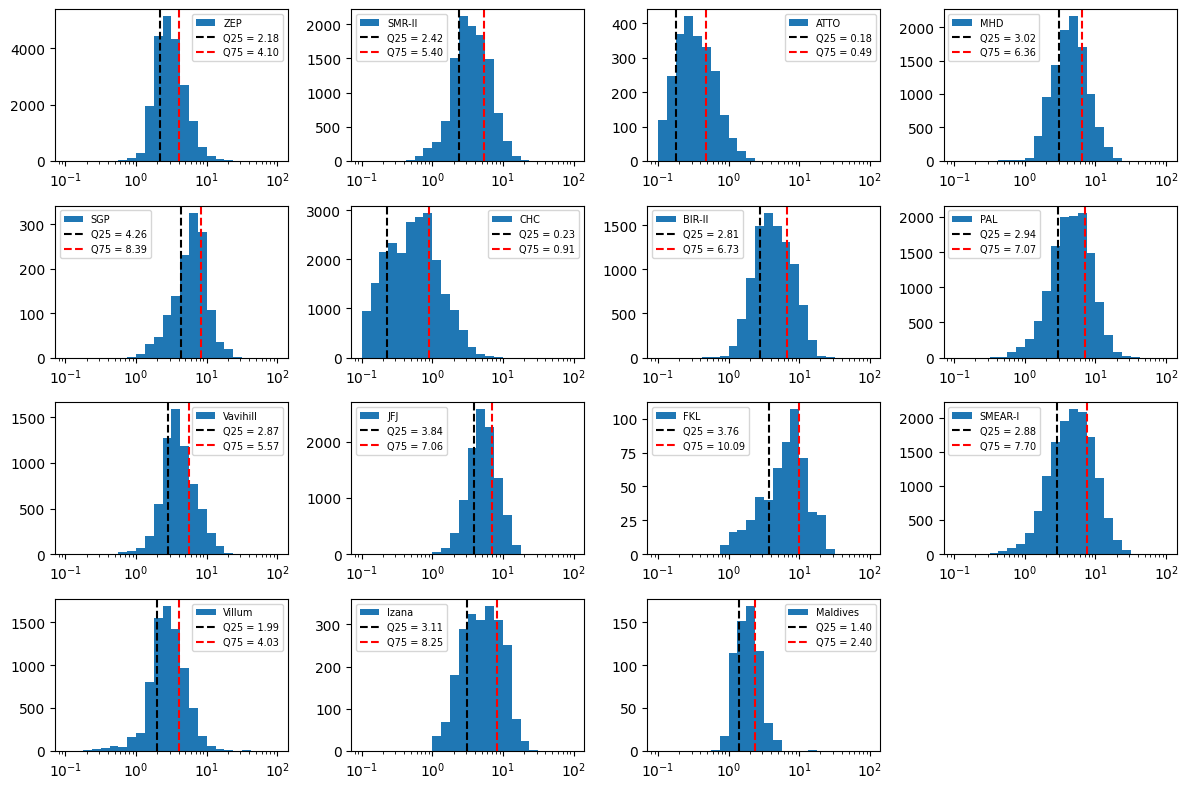

In [77]:
bins = np.logspace(-1, 2, 25)
plt.figure(figsize=[12, 8])
for x, station in enumerate(AitAccRatio.station.values):
    plt.subplot(4, 4, x + 1)
    data = AitAccRatio.sel(station=station).values.ravel()
    plt.hist(data, bins=bins, label=station)

    q25, q75 = np.nanquantile(data, [0.25, 0.75])
    plt.axvline(q25, color='k', linestyle='--', linewidth=1.5,
                label=f'Q25 = {q25:.2f}')
    plt.axvline(q75, color='r', linestyle='--', linewidth=1.5,
                label=f'Q75 = {q75:.2f}')

    plt.xscale('log')
    plt.legend(fontsize=7)
plt.tight_layout()

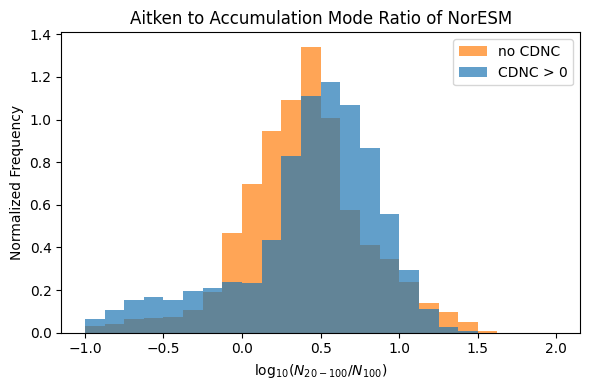

In [11]:
bins = np.linspace(-1, 2, 25)
plt.figure(figsize=[6, 4])
plt.hist(
    [np.log10(AitAccRatio.values.flatten()),np.log10(AitAccRatio2.values.flatten())], 
    density = True,
    bins = bins,
    stacked = False,
    histtype = 'stepfilled',
    alpha = 0.7,
    label=['CDNC > 0', 'no CDNC']
)
plt.ylabel('Normalized Frequency')
plt.xlabel('log$_{10}$($N_{20-100}/N_{100}$)')
plt.title('Aitken to Accumulation Mode Ratio of NorESM')
plt.legend()
plt.tight_layout()

## 4. Define the high-Aitken and high-accumulation populations

Lower quartile of the ratio = accumulation-dominated (`BigAcc`); upper quartile =
Aitken-dominated (`BigAit`). Cells below are two binning conventions (global vs
per-station quartile) — the per-station one is carried forward.

In [12]:
# --- Global-quartile split (kept for reference; superseded by per-station below) ---
mask = (AitAccRatio <= AitAccRatio.quantile(0.25)).compute().reset_coords("radius", drop=True)
BigAcc = CCN_all.where(mask, drop=True)

mask = (AitAccRatio >= AitAccRatio.quantile(0.75)).compute().reset_coords("radius", drop=True)
BigAit = CCN_all.where(mask, drop=True)


In [13]:
# --- Per-station quartile split (THIS is the version used downstream) ---
# Collapse every dim except 'station' so quartiles are computed per station,
# avoiding a few polluted stations dominating the global cut.
dims = [d for d in AitAccRatio.dims if d != "station"]

# lower quartile per station -> high accumulation mode
q25 = AitAccRatio.quantile(0.25, dim=dims)
mask_low = (AitAccRatio <= q25)
BigAcc = CCN_all.where(mask_low)

# upper quartile per station -> high Aitken mode
q75 = AitAccRatio.quantile(0.75, dim=dims)
mask_high = (AitAccRatio >= q75)
BigAit = CCN_all.where(mask_high)


In [14]:
BigAcc = BigAcc.where(BigAcc.CDNC.notnull(), drop = True)
BigAit = BigAit.where(BigAit.CDNC.notnull(), drop = True)

## 5. Stack into (CCN, CDNC, updraft) sample pairs

Broadcast against `WSUB` and flatten station/time/lev into a single `sample`
dimension. CDNC/Updraft don't vary with the CCN cutoff radius, so that axis is dropped.
These `Pairs_*` datasets are the regression inputs. For future, it is possible to add more variables to the pairs in this block.

In [42]:
CDNC_b, CCN_b, WSUB_b = xr.broadcast(BigAcc.CDNC, BigAcc.CCN, ds.WSUB)
Pairs_acc = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b,
    "Updraft": WSUB_b
}).stack(sample=("station", "time", "lev"))
Pairs_acc = Pairs_acc.where(Pairs_acc.CDNC.notnull(), drop=True)
Pairs_acc['CDNC'] = Pairs_acc['CDNC'].isel(radius = 0)
Pairs_acc['Updraft'] = Pairs_acc['Updraft'].isel(radius = 0)

AttributeError: 'Dataset' object has no attribute 'WSUB'

In [16]:
CDNC_b, CCN_b, WSUB_b = xr.broadcast(BigAit.CDNC, BigAit.CCN, ds.WSUB)
Pairs_ait = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b,
    "Updraft": WSUB_b
}).stack(sample=("station", "time", "lev"))
Pairs_ait = Pairs_ait.where(Pairs_ait.CDNC.notnull(), drop=True)
Pairs_ait['CDNC'] = Pairs_ait['CDNC'].isel(radius = 0)
Pairs_ait['Updraft'] = Pairs_ait['Updraft'].isel(radius = 0)

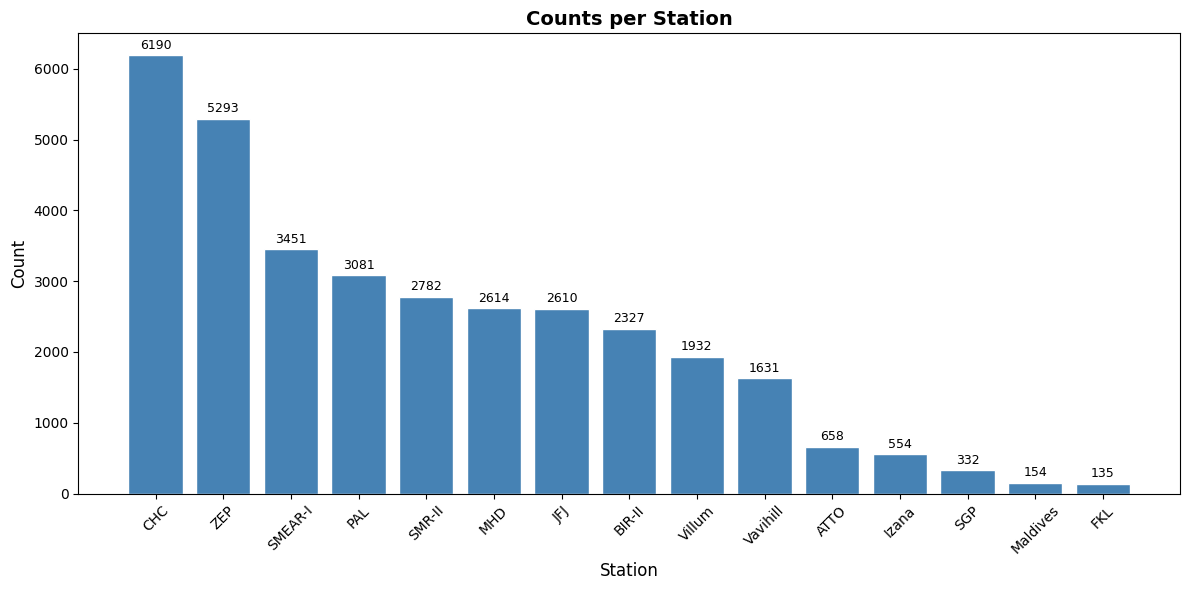

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Count occurrences of each station
station_counts = pd.Series(Pairs_acc.station.values).value_counts()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(station_counts.index, station_counts.values, color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, station_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_title('Counts per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [48]:
print(Pairs_acc)

<xarray.Dataset> Size: 19MB
Dimensions:   (sample: 33744, radius: 61)
Coordinates:
    quantile  float64 8B 0.25
  * radius    (radius) float64 488B 1.0 1.109 1.23 1.365 ... 407.4 451.9 501.2
  * sample    (sample) object 270kB MultiIndex
  * station   (sample) <U8 1MB 'ZEP' 'ZEP' 'ZEP' ... 'Maldives' 'Maldives'
  * time      (sample) datetime64[ns] 270kB 2012-01-02 ... 2014-09-19T12:00:00
  * lev       (sample) float64 270kB 820.9 859.5 887.0 ... 691.4 691.4 691.4
Data variables:
    CDNC      (sample) float32 135kB 49.7 57.86 57.17 51.36 ... 46.5 40.69 53.6
    CCN       (radius, sample) float64 16MB 179.9 182.4 170.0 ... 0.2828 0.2231
    Updraft   (sample) float32 135kB dask.array<chunksize=(33744,), meta=np.ndarray>


## 6. Susceptibility regression (module function)

Uses `Function.build_susceptibility_dataset_pooled` from `PeterChurchillFunctions.py`.
The high-Aitken and high-accumulation populations are already pooled across stations,
so this regresses log CDNC on log CCN over the **whole pool at once** (no per-station
loop), within fixed physical updraft bands (`<=0.2 / 0.2-0.5 / >0.5 / Total` m/s or by updraft quantiles `q0-q75, q75-q90, q90-q100, Total`)
The slope is the susceptibility S = d ln CDNC / d ln CCN.

In [18]:
# Pooled susceptibility regressor from the shared module (keeps every notebook
# consistent). Operates on the sample-stacked Pairs_* datasets and returns
# (radius, updraft_q) with fixed physical updraft bins:
#     '<=0.2' / '0.2-0.5' / '>0.5' / 'Total'
# For a station-resolved result use build_susceptibility_dataset_by_station instead.


In [19]:
Updraft.where(BigAit.CDNC.notnull(), drop=True).quantile([0,0.75, 0.9,1]).values

array([0.2       , 0.31082115, 0.41328895, 1.51741588])

In [20]:
# High-Aitken population susceptibility (pooled across stations, updraft-stratified)
BigAitReg_ds = Function.build_susceptibility_dataset_pooled(
    Pairs_ait,
    radii,
    bin_dim='radius',
    output_name='BigAitReg',
    updraft_bins= Updraft.where(BigAit.CDNC.notnull(), drop=True).quantile([0,0.75, 0.9,1]).values,
    updraft_labels=('Q0-Q75','Q75-Q90','Q90-Q100','Total')
)


In [21]:
# High-accumulation population susceptibility (pooled across stations, updraft-stratified)
BigAccReg_ds = Function.build_susceptibility_dataset_pooled(
    Pairs_acc,
    radii,
    bin_dim='radius',
    output_name='BigAccReg',
    updraft_bins= Updraft.where(BigAcc.CDNC.notnull(), drop=True).quantile([0,0.75, 0.9,1]).values,
    updraft_labels=('Q0-Q75','Q75-Q90','Q90-Q100','Total')
)


## 7. Susceptibility resolved by vertical level

Same regression but looped per pressure level instead of pooled, to see how
susceptibility varies with height.

In [22]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats

acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
all_levels = acc_count.index

# Per-level susceptibility: same equal-count + bin-MEDIAN convention as the
# pooled module regressor, just looped per pressure level instead of pooled.
N_BINS = 100

BigAccReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
    },
    coords={"radius": radii, "lev": all_levels},
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for level in all_levels:
        for r in range(len(radii)):

            # --- Extract and clean (drop non-positive / non-finite before log) ---
            CCN  = Pairs_acc.CCN.sel(lev=level).isel(radius=r).values
            CDNC = Pairs_acc.CDNC.sel(lev=level).values
            valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
            lx = np.log10(CCN[valid])
            ly = np.log10(CDNC[valid])

            if lx.size < 10:
                continue

            # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
            #     equal datapoint count, take each group's MEDIAN ---
            order = np.argsort(lx)
            lx_groups = np.array_split(lx[order], N_BINS)
            ly_groups = np.array_split(ly[order], N_BINS)

            lx_med = np.array([np.median(g) for g in lx_groups if g.size > 0])
            ly_med = np.array([np.median(g) for g in ly_groups if g.size > 0])

            finite = np.isfinite(lx_med) & np.isfinite(ly_med)
            if finite.sum() < 4:
                continue

            # --- Regression through the bin medians ---
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                lx_med[finite], ly_med[finite]
            )

            loc = {"radius": radii[r], "lev": level}
            BigAccReg_lev_ds["slope"].loc[loc]     = slope
            BigAccReg_lev_ds["r_value"].loc[loc]   = r_value
            BigAccReg_lev_ds["std_err"].loc[loc]   = std_err
            BigAccReg_lev_ds["intercept"].loc[loc] = intercept


In [23]:
acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
ait_count = pd.Series(Pairs_ait.lev.values).value_counts().sort_index()
all_levels = ait_count.index.union(acc_count.index)


In [24]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats

acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
ait_count = pd.Series(Pairs_ait.lev.values).value_counts().sort_index()
all_levels = ait_count.index

# Per-level susceptibility: same equal-count + bin-MEDIAN convention as the
# pooled module regressor, just looped per pressure level instead of pooled.
N_BINS = 100

BigAitReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
    },
    coords={"radius": radii, "lev": all_levels},
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for level in all_levels:
        for r in range(len(radii)):

            # --- Extract and clean (drop non-positive / non-finite before log) ---
            CCN  = Pairs_ait.CCN.sel(lev=level).isel(radius=r).values
            CDNC = Pairs_ait.CDNC.sel(lev=level).values
            valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
            lx = np.log10(CCN[valid])
            ly = np.log10(CDNC[valid])

            if lx.size < 10:
                continue

            # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
            #     equal datapoint count, take each group's MEDIAN ---
            order = np.argsort(lx)
            lx_groups = np.array_split(lx[order], N_BINS)
            ly_groups = np.array_split(ly[order], N_BINS)

            lx_med = np.array([np.median(g) for g in lx_groups if g.size > 0])
            ly_med = np.array([np.median(g) for g in ly_groups if g.size > 0])

            finite = np.isfinite(lx_med) & np.isfinite(ly_med)
            if finite.sum() < 4:
                continue

            # --- Regression through the bin medians ---
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                lx_med[finite], ly_med[finite]
            )

            loc = {"radius": radii[r], "lev": level}
            BigAitReg_lev_ds["slope"].loc[loc]     = slope
            BigAitReg_lev_ds["r_value"].loc[loc]   = r_value
            BigAitReg_lev_ds["std_err"].loc[loc]   = std_err
            BigAitReg_lev_ds["intercept"].loc[loc] = intercept


## 8. Susceptibility maps: diameter × pressure level

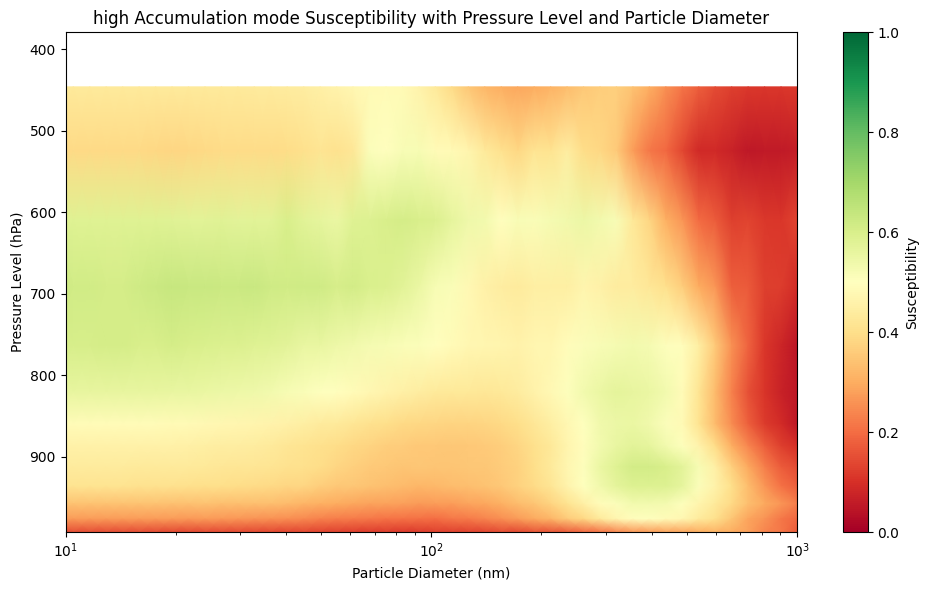

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

mesh = ax.pcolormesh(
    BigAccReg_lev_ds['radius'] * 2,
    BigAccReg_lev_ds['lev'],
    BigAccReg_lev_ds['slope'].T,
    shading='gouraud',
    vmin=0,
    vmax=1,
    cmap='RdYlGn'
)
ax.set_xscale('log')
ax.set_xlim(10,1000)
ax.invert_yaxis()
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Pressure Level (hPa)')
ax.set_title('high Accumulation mode Susceptibility with Pressure Level and Particle Diameter')

plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()

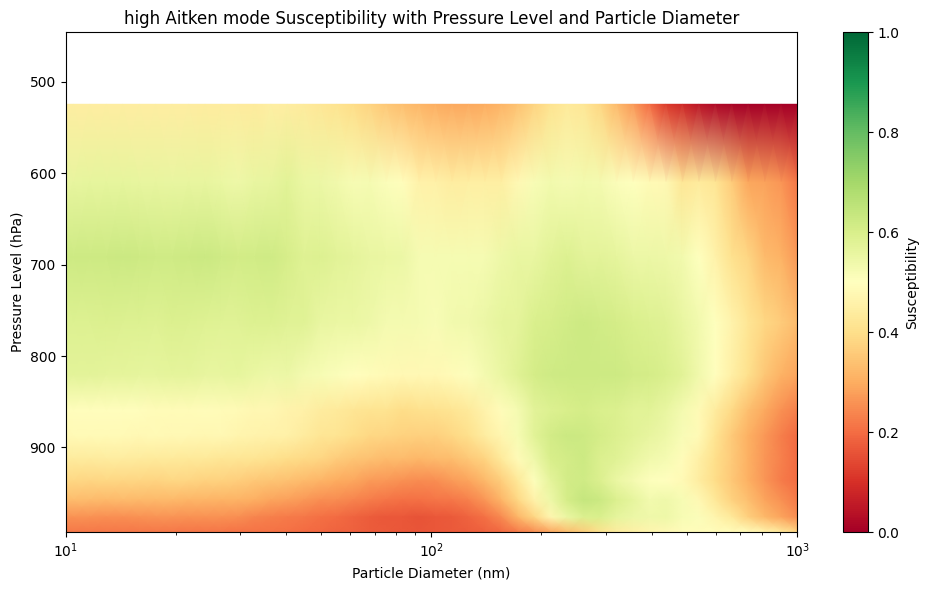

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

mesh = ax.pcolormesh(
    BigAitReg_lev_ds['radius'] * 2,
    BigAitReg_lev_ds['lev'],
    BigAitReg_lev_ds['slope'].T,
    shading='gouraud',
    vmin=0,
    vmax=1,
    cmap='RdYlGn'
)
ax.set_xscale('log')
ax.set_xlim(10,1000)
ax.invert_yaxis()
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Pressure Level (hPa)')
ax.set_title('high Aitken mode Susceptibility with Pressure Level and Particle Diameter')

plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()

## 9. Susceptibility vs particle diameter (updraft-stratified)

Slope (solid) and correlation r (dashed) vs cutoff diameter, one curve per updraft
band, for each mode population.

In [27]:
BigAccReg_ds

<xarray.Dataset> Size: 8kB
Dimensions:    (radius: 61, updraft_q: 4)
Coordinates:
  * radius     (radius) float64 488B 1.0 1.109 1.23 1.365 ... 407.4 451.9 501.2
  * updraft_q  (updraft_q) <U8 128B 'Q0-Q75' 'Q75-Q90' 'Q90-Q100' 'Total'
Data variables:
    slope      (radius, updraft_q) float64 2kB 0.4629 0.4773 ... 0.09853 0.1051
    r_value    (radius, updraft_q) float64 2kB 0.9404 0.9435 ... 0.5083 0.8089
    std_err    (radius, updraft_q) float64 2kB 0.01691 0.01693 ... 0.007718
    intercept  (radius, updraft_q) float64 2kB 0.5391 0.7018 ... 1.991 1.857
Attributes:
    name:     BigAccReg

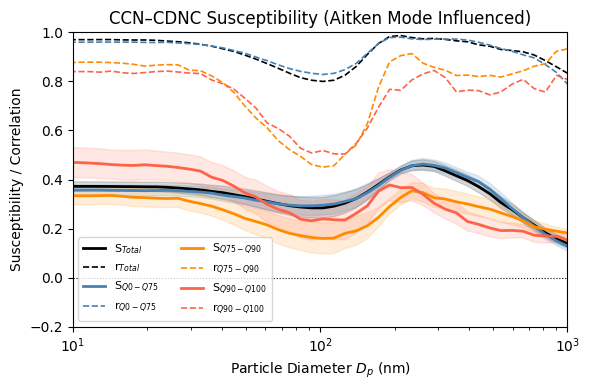

In [43]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {
    'Total':    'black',
    'Q0-Q75':   'steelblue',
    'Q75-Q90':  'darkorange',
    'Q90-Q100': 'tomato',
}

for q_label, color in colors.items():
    ds = BigAitReg_ds.sel(updraft_q=q_label)
    
    ax.plot(ds['radius']*2, ds['slope'],
            color=color, linewidth=2,
            label=f'S$_{{{q_label}}}$')
    ax.fill_between(ds['radius']*2,
                    ds['slope'] - 1.98*ds['std_err'],
                    ds['slope'] + 1.98*ds['std_err'],
                    color=color, alpha=0.15)
    ax.plot(ds['radius']*2, ds['r_value'],
            '--', color=color, linewidth=1.2,
            label=f'r$_{{{q_label}}}$')

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('CCN–CDNC Susceptibility (Aitken Mode Influenced)')
ax.set_xlabel('Particle Diameter $D_p$ (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([-0.2, 1])
ax.set_xlim([10, 1000])
ax.set_xscale('log')
ax.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

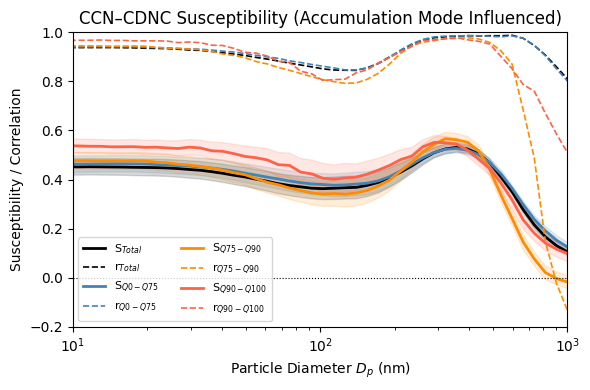

In [44]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {
    'Total':    'black',
    'Q0-Q75':   'steelblue',
    'Q75-Q90':  'darkorange',
    'Q90-Q100': 'tomato',
}

for q_label, color in colors.items():
    ds = BigAccReg_ds.sel(updraft_q=q_label)
    
    ax.plot(ds['radius']*2, ds['slope'],
            color=color, linewidth=2,
            label=f'S$_{{{q_label}}}$')
    ax.fill_between(ds['radius']*2,
                    ds['slope'] - 1.98*ds['std_err'],
                    ds['slope'] + 1.98*ds['std_err'],
                    color=color, alpha=0.15)
    ax.plot(ds['radius']*2, ds['r_value'],
            '--', color=color, linewidth=1.2,
            label=f'r$_{{{q_label}}}$')

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('CCN–CDNC Susceptibility (Accumulation Mode Influenced)')
ax.set_xlabel('Particle Diameter $D_p$ (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([-0.2, 1])
ax.set_xlim([10, 1000])
ax.set_xscale('log')
ax.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

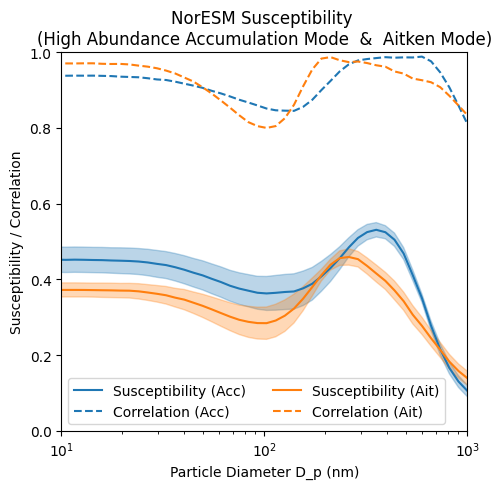

In [30]:
fig, ax = plt.subplots(figsize=[5, 5])

# Accumulation mode
ax.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['slope'].sel(updraft_q = 'Total'), label='Susceptibility (Acc)', color='C0')
ax.fill_between(BigAccReg_ds['radius']*2,
                BigAccReg_ds['slope'].sel(updraft_q = 'Total')-1.98*BigAccReg_ds['std_err'].sel(updraft_q = 'Total'),
                BigAccReg_ds['slope'].sel(updraft_q = 'Total')+1.98*BigAccReg_ds['std_err'].sel(updraft_q = 'Total'),
                alpha=0.3, color='C0')
ax.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['r_value'].sel(updraft_q = 'Total'), '--', color='C0', label='Correlation (Acc)')

# Aitken mode
ax.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['slope'].sel(updraft_q = 'Total'), label='Susceptibility (Ait)', color='C1')
ax.fill_between(BigAitReg_ds['radius']*2,
                BigAitReg_ds['slope'].sel(updraft_q = 'Total')-1.98*BigAitReg_ds['std_err'].sel(updraft_q = 'Total'),
                BigAitReg_ds['slope'].sel(updraft_q = 'Total')+1.98*BigAitReg_ds['std_err'].sel(updraft_q = 'Total'),
                alpha=0.3, color='C1')
ax.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['r_value'].sel(updraft_q = 'Total'), '--', color='C1', label='Correlation (Ait)')

ax.legend(ncols = 2)
ax.set_title('NorESM Susceptibility \n(High Abundance Accumulation Mode  &  Aitken Mode)')
ax.set_xlabel('Particle Diameter D_p (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([0, 1])
ax.set_xlim([10, 1000])
ax.set_xscale('log')
plt.tight_layout()

## 10. CCN–CDNC scatter diagnostics

Hexbin density / binned-mean / per-quartile regression views of the underlying
log CCN – log CDNC relationship at selected cutoff radii.

44.7744227713668


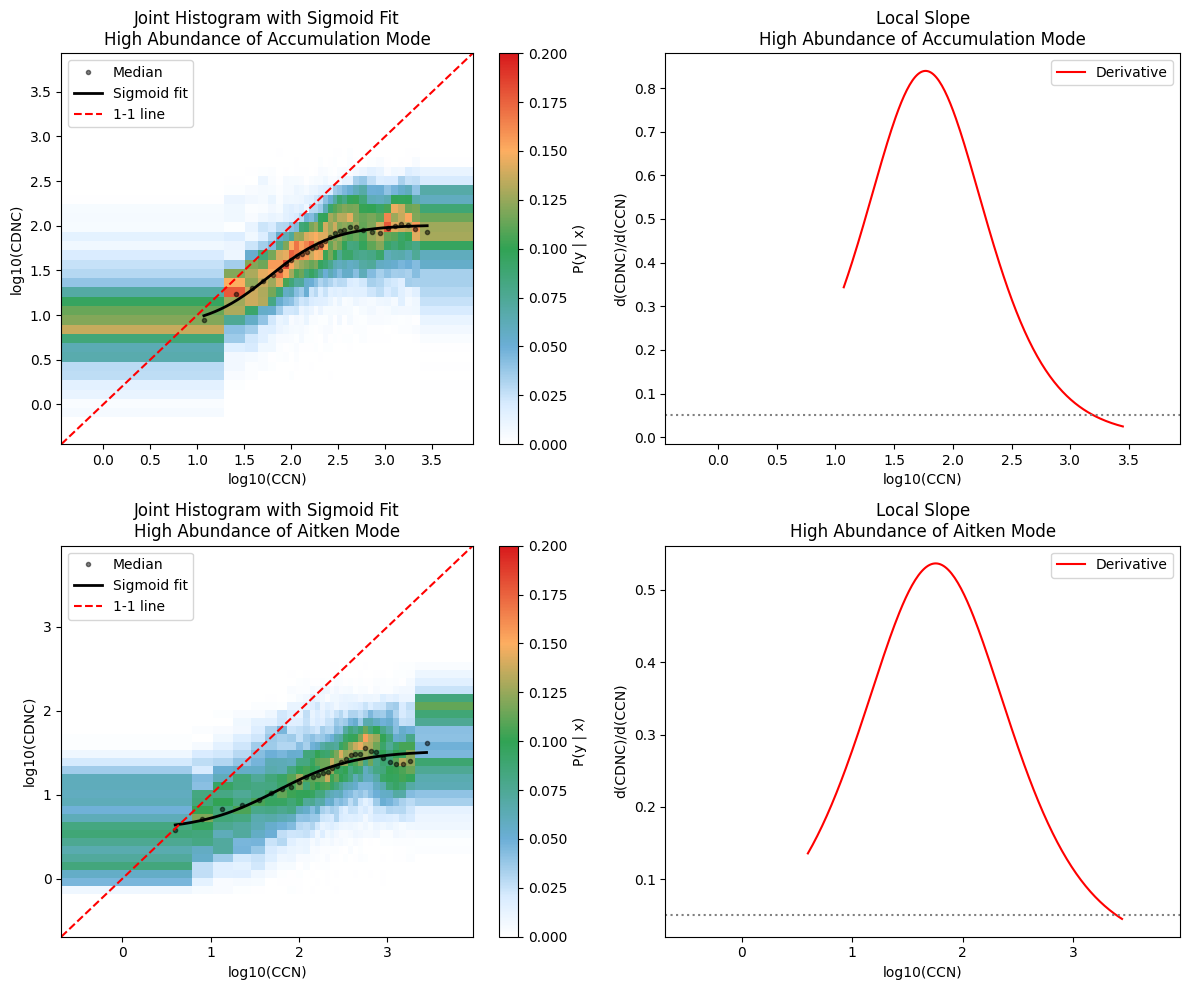

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import curve_fit
print(2 * Pairs_acc.radius.values[30])  # ~50 nm radius (100 nm diameter)
# --- Shared colormap (paper style) ---
cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)

# --- Sigmoid and its analytic derivative ---
def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def sigmoid_derivative(x, L, x0, k, b):
    exp_term = np.exp(-k * (x - x0))
    return (L * k * exp_term) / (1 + exp_term) ** 2

def prep_population(pairs_ds, radius_idx=30, n_bins=30):
    """Equal-frequency x-binning + per-bin median + sigmoid fit for one population."""
    x = np.log10(pairs_ds["CCN"].isel(radius=radius_idx).values.flatten())
    y = np.log10(pairs_ds["CDNC"].values.flatten())

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    g_min = min(x.min(), y.min())
    g_max = max(x.max(), y.max())

    # Equal-FREQUENCY bins in x (quantile edges); y kept linear
    xbins = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    ybins = np.linspace(y.min(), y.max(), 30)

    H, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])
    H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))   # P(y | x) per x-bin

    # Per-x-bin median of y
    x_centers = 0.5 * (xbins[:-1] + xbins[1:])
    y_median = np.full(n_bins, np.nan)
    x_median = np.full(n_bins, np.nan)

    for i in range(n_bins):
        m = (x >= xbins[i]) & (x < xbins[i + 1])
        if np.any(m):
            y_median[i] = np.median(y[m])
            x_median[i] = np.median(x[m])


    valid = np.isfinite(y_median)
    x_fit, y_fit = x_median[valid], y_median[valid]

    # Sigmoid fit through the bin medians
    p0 = [y_fit.max() - y_fit.min(), np.median(x_fit), 1, y_fit.min()]
    params, _ = curve_fit(sigmoid, x_fit, y_fit, p0=p0, maxfev=10000)

    x_smooth = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_sigmoid = sigmoid(x_smooth, *params)
    y_deriv = sigmoid_derivative(x_smooth, *params)

    return dict(
        xedges=xedges, yedges=yedges, H_norm=H_norm,
        x_fit=x_fit, y_fit=y_fit,
        x_smooth=x_smooth, y_sigmoid=y_sigmoid, y_deriv=y_deriv,
        g_min=g_min, g_max=g_max,
    )

# --- Build both populations ---
populations = [
    ("High Abundance of Accumulation Mode", prep_population(Pairs_acc)),
    ("High Abundance of Aitken Mode",       prep_population(Pairs_ait)),
]

# --- 2x2 layout: rows = Acc / Ait, cols = joint histogram | derivative ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (title, d) in enumerate(populations):
    ax_hist, ax_deriv = axes[row, 0], axes[row, 1]

    # Left: joint histogram + median + sigmoid + 1:1 line
    pcm = ax_hist.pcolormesh(
        d["xedges"], d["yedges"], d["H_norm"].T,
        cmap=cmap, shading="auto", vmin=0, vmax=0.2,
    )
    ax_hist.plot(d["x_fit"], d["y_fit"], "k.", alpha=0.5, label="Median")
    ax_hist.plot(d["x_smooth"], d["y_sigmoid"], "k-", linewidth=2, label="Sigmoid fit")
    ax_hist.plot([d["g_min"], d["g_max"]], [d["g_min"], d["g_max"]],
                 ls="--", c="red", label="1-1 line")
    ax_hist.set_xlim(d["g_min"], d["g_max"])
    ax_hist.set_ylim(d["g_min"], d["g_max"])
    ax_hist.set_xlabel("log10(CCN)")
    ax_hist.set_ylabel("log10(CDNC)")
    ax_hist.set_title(f"Joint Histogram with Sigmoid Fit\n{title}")
    ax_hist.legend()
    fig.colorbar(pcm, ax=ax_hist, label="P(y | x)")

    # Right: sigmoid derivative (local susceptibility) next to its graph
    ax_deriv.plot(d["x_smooth"], d["y_deriv"], "r-", label="Derivative")
    ax_deriv.axhline(0.05, ls=":", c="grey")
    ax_deriv.set_xlim(d["g_min"], d["g_max"])
    ax_deriv.set_xlabel("log10(CCN)")
    ax_deriv.set_ylabel("d(CDNC)/d(CCN)")
    ax_deriv.set_title(f"Local Slope\n{title}")
    ax_deriv.legend()

plt.tight_layout()
plt.show()

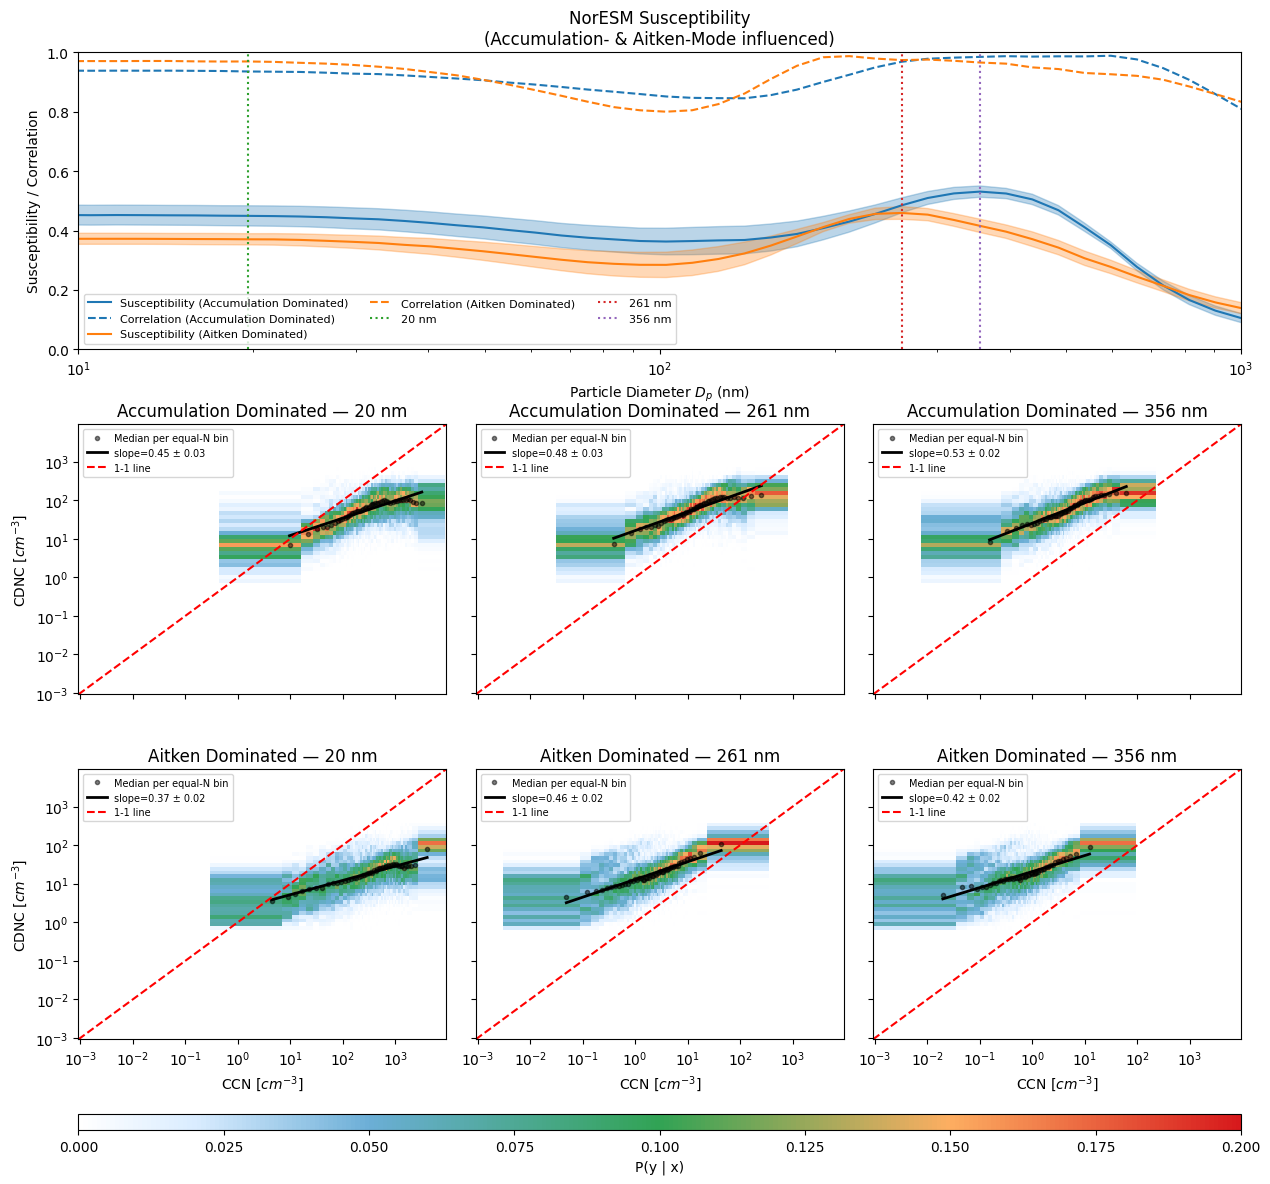

In [32]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator

cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)

n_bins = 50
pow_fmt = FuncFormatter(lambda v, _: rf"$10^{{{int(v)}}}$")

# (label, regression ds, pairs ds, colour) for each mode
modes = [
    ("Accumulation Dominated", BigAccReg_ds, Pairs_acc, 'C0'),
    ("Aitken Dominated", BigAitReg_ds, Pairs_ait, 'C1'),
]

diam = BigAccReg_ds['radius'].values * 2  # nm; same radius grid for both

# --- choose the three cutoff indices (shared across both rows) ---
imax_acc = int(np.nanargmax(BigAccReg_ds['slope'].sel(updraft_q='Total').values))
imax_ait = int(np.nanargmax(BigAitReg_ds['slope'].sel(updraft_q='Total').values))
i20 = int(np.nanargmin(np.abs(diam - 20)))
panel_idxs = [i20, imax_ait, imax_acc]
panel_labels = [f'{diam[i20]:.0f} nm',
                f'{diam[imax_ait]:.0f} nm',
                f'{diam[imax_acc]:.0f} nm']


def panel_data(reg_ds, pairs_ds, ridx):
    ccn  = pairs_ds['CCN'].isel(radius=ridx).values.ravel()
    cdnc = pairs_ds['CDNC'].values.ravel()
    valid = np.isfinite(ccn) & np.isfinite(cdnc) & (ccn > 0) & (cdnc > 0)
    lx, ly = np.log10(ccn[valid]), np.log10(cdnc[valid])

    bins = np.unique(np.quantile(lx, np.linspace(0, 1, n_bins + 1)))
    lx_med, ly_med = [], []
    for b in range(len(bins) - 1):
        if b == len(bins) - 2:
            m = (lx >= bins[b]) & (lx <= bins[b+1])
        else:
            m = (lx >= bins[b]) & (lx < bins[b+1])
        if m.sum() >= 2:
            lx_med.append(np.median(lx[m]))
            ly_med.append(np.median(ly[m]))
    lx_med, ly_med = np.array(lx_med), np.array(ly_med)

    ybins = np.linspace(ly.min(), ly.max(), 30)
    H, xedges, yedges = np.histogram2d(lx, ly, bins=[bins, ybins])
    H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))

    return dict(
        lx=lx, ly=ly, lx_med=lx_med, ly_med=ly_med,
        xedges=xedges, yedges=yedges, H_norm=H_norm,
        slope=float(reg_ds['slope'].sel(updraft_q='Total').isel(radius=ridx)),
        intercept=float(reg_ds['intercept'].sel(updraft_q='Total').isel(radius=ridx)),
        std_err=float(reg_ds['std_err'].sel(updraft_q='Total').isel(radius=ridx)),
    )

# precompute all six panels + global shared range
pdata = {}
for label, reg_ds, pairs_ds, _ in modes:
    for ridx in panel_idxs:
        pdata[(label, ridx)] = panel_data(reg_ds, pairs_ds, ridx)

g_min = min(min(d['lx'].min(), d['ly'].min()) for d in pdata.values())
g_max = max(max(d['lx'].max(), d['ly'].max()) for d in pdata.values())

# --- layout: curve (row 0) + two histogram rows (1,2) + colorbar (row 3) ---
fig = plt.figure(figsize=(15, 14))
gs = fig.add_gridspec(4, 3, height_ratios=[1.1, 1, 1, 0.06],
                      hspace=0.35, wspace=0.08)

# top: shared susceptibility profile
ax_curve = fig.add_subplot(gs[0, :])
for label, reg_ds, _, colour in modes:
    sl = reg_ds['slope'].sel(updraft_q='Total')
    se = reg_ds['std_err'].sel(updraft_q='Total')
    ax_curve.plot(diam, sl, color=colour, label=f'Susceptibility ({label})')
    ax_curve.fill_between(diam, sl - 1.98*se, sl + 1.98*se, alpha=0.3, color=colour)
    ax_curve.plot(diam, reg_ds['r_value'].sel(updraft_q='Total'), '--',
                  color=colour, label=f'Correlation ({label})')
for ridx, c in zip(panel_idxs, ['tab:green', 'tab:red', 'tab:purple']):
    ax_curve.axvline(diam[ridx], color=c, linestyle=':', label=f'{diam[ridx]:.0f} nm')
ax_curve.set_title('NorESM Susceptibility\n(Accumulation- & Aitken-Mode influenced)')
ax_curve.set_xlabel('Particle Diameter $D_p$ (nm)')
ax_curve.set_ylabel('Susceptibility / Correlation')
ax_curve.set_ylim([0, 1])
ax_curve.set_xlim([10, 1000])
ax_curve.set_xscale('log')
ax_curve.legend(ncols=3, fontsize=8)

# two histogram rows, sharing one common axis
first_ax = None
pcm = None
for row, (label, reg_ds, pairs_ds, colour) in enumerate(modes):
    for col, ridx in enumerate(panel_idxs):
        d = pdata[(label, ridx)]
        ax = fig.add_subplot(gs[1 + row, col],
                             sharex=first_ax, sharey=first_ax)
        if first_ax is None:
            first_ax = ax

        pcm = ax.pcolormesh(d['xedges'], d['yedges'], d['H_norm'].T,
                            cmap=cmap, shading="auto", vmin=0, vmax=0.2)
        ax.plot(d['lx_med'], d['ly_med'], "k.", alpha=0.5,
                label="Median per equal-N bin")
        xfit = np.array([d['lx_med'].min(), d['lx_med'].max()])
        ax.plot(xfit, d['intercept'] + d['slope'] * xfit, "k-", linewidth=2,
                label=f"slope={d['slope']:.2f} ± {1.98*d['std_err']:.2f}")
        ax.plot([g_min, g_max], [g_min, g_max], ls="--", c="red", label="1-1 line")

        ax.set_xlim(g_min, g_max)
        ax.set_ylim(g_min, g_max)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_formatter(pow_fmt)
        ax.yaxis.set_major_formatter(pow_fmt)
        ax.set_title(f"{label} — {panel_labels[col]}")
        ax.legend(fontsize=7, loc='upper left')

        # x labels only on bottom row; y labels only on first column
        if row == len(modes) - 1:
            ax.set_xlabel("CCN [$cm^{-3}$]")
        else:
            ax.tick_params(labelbottom=False)
        if col == 0:
            ax.set_ylabel("CDNC [$cm^{-3}$]")
        else:
            ax.tick_params(labelleft=False)

# horizontal colorbar under everything
cax = fig.add_subplot(gs[3, :])
fig.colorbar(pcm, cax=cax, orientation='horizontal', label="P(y | x)")

plt.show()

/tmp/ipykernel_2027234/968565803.py:33: RuntimeWarning: invalid value encountered in divide
  H2_norm = H2 / H2.sum(axis=1, keepdims=True)


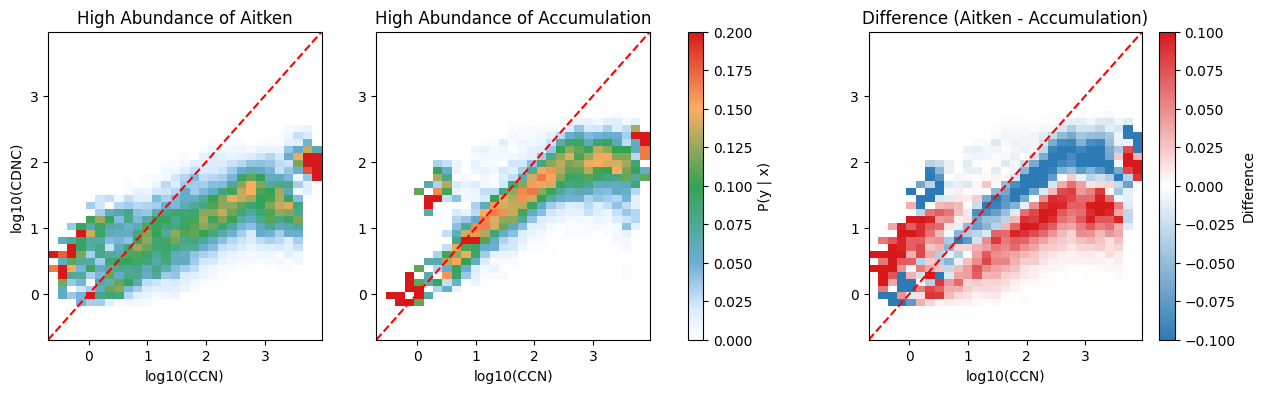

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Data ---
x1 = np.log10(Pairs_ait['CCN'].isel(radius=30))
y1 = np.log10(Pairs_ait['CDNC'])

x2 = np.log10(Pairs_acc['CCN'].isel(radius=30))
y2 = np.log10(Pairs_acc['CDNC'])

# Flatten & remove NaNs (important!)
x1, y1 = x1.values.flatten(), y1.values.flatten()
x2, y2 = x2.values.flatten(), y2.values.flatten()

mask1 = np.isfinite(x1) & np.isfinite(y1)
mask2 = np.isfinite(x2) & np.isfinite(y2)

x1, y1 = x1[mask1], y1[mask1]
x2, y2 = x2[mask2], y2[mask2]
Graph_min = np.min([np.min(x1),np.min(y1),np.min(x2),np.min(y2)])
Graph_max = np.max([np.max(x1),np.max(y1),np.max(x2),np.max(y2)])
# --- bin edges (shared!) ---
xbins = np.linspace(min(x1.min(), x2.min()), max(x1.max(), x2.max()), 30)
ybins = np.linspace(min(y1.min(), y2.min()), max(y1.max(), y2.max()), 30)

# --- Histograms ---
H1, xedges, yedges = np.histogram2d(x1, y1, bins=[xbins, ybins])
H2, _, _ = np.histogram2d(x2, y2, bins=[xbins, ybins])

# --- Normalize per x-bin ---
H1_norm = H1 / H1.sum(axis=1, keepdims=True)
H2_norm = H2 / H2.sum(axis=1, keepdims=True)

H1_norm = np.nan_to_num(H1_norm)
H2_norm = np.nan_to_num(H2_norm)

# --- Difference ---
H_diff = H1_norm - H2_norm

# --- Colormaps ---
cmap_main = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ]
)

cmap_diff = LinearSegmentedColormap.from_list(
    "diff_map",
    [
        (0.0, "#2c7bb6"),  # blue
        (0.5, "#ffffff"),  # zero
        (1.0, "#d7191c"),  # red
    ]
)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Aitken
pcm1 = axes[0].pcolormesh(
    xedges, yedges, H1_norm.T,
    cmap=cmap_main, shading='auto',
    vmin=0, vmax=0.2
)
axes[0].set_title('High Abundance of Aitken')
axes[0].set_xlabel('log10(CCN)')
axes[0].set_ylabel('log10(CDNC)')
axes[0].set_ylim([Graph_min,Graph_max])
axes[0].set_xlim([Graph_min,Graph_max])
axes[0].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Accumulation
pcm2 = axes[1].pcolormesh(
    xedges, yedges, H2_norm.T,
    cmap=cmap_main, shading='auto',
    vmin=0, vmax=0.2
)
axes[1].set_title('High Abundance of Accumulation')
axes[1].set_xlabel('log10(CCN)')
axes[1].set_ylim([Graph_min,Graph_max])
axes[1].set_xlim([Graph_min,Graph_max])
axes[1].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Difference
pcm3 = axes[2].pcolormesh(
    xedges, yedges, H_diff.T,
    cmap=cmap_diff, shading='auto',
    vmin=-0.1, vmax=0.1
)
axes[2].set_title('Difference (Aitken - Accumulation)')
axes[2].set_xlabel('log10(CCN)')
axes[2].set_ylim([Graph_min,Graph_max])
axes[2].set_xlim([Graph_min,Graph_max])
axes[2].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Colorbars
fig.colorbar(pcm1, ax=axes[:2], label='P(y | x)')
fig.colorbar(pcm3, ax=axes[2], label='Difference')

plt.show()

/tmp/ipykernel_2027234/60067575.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


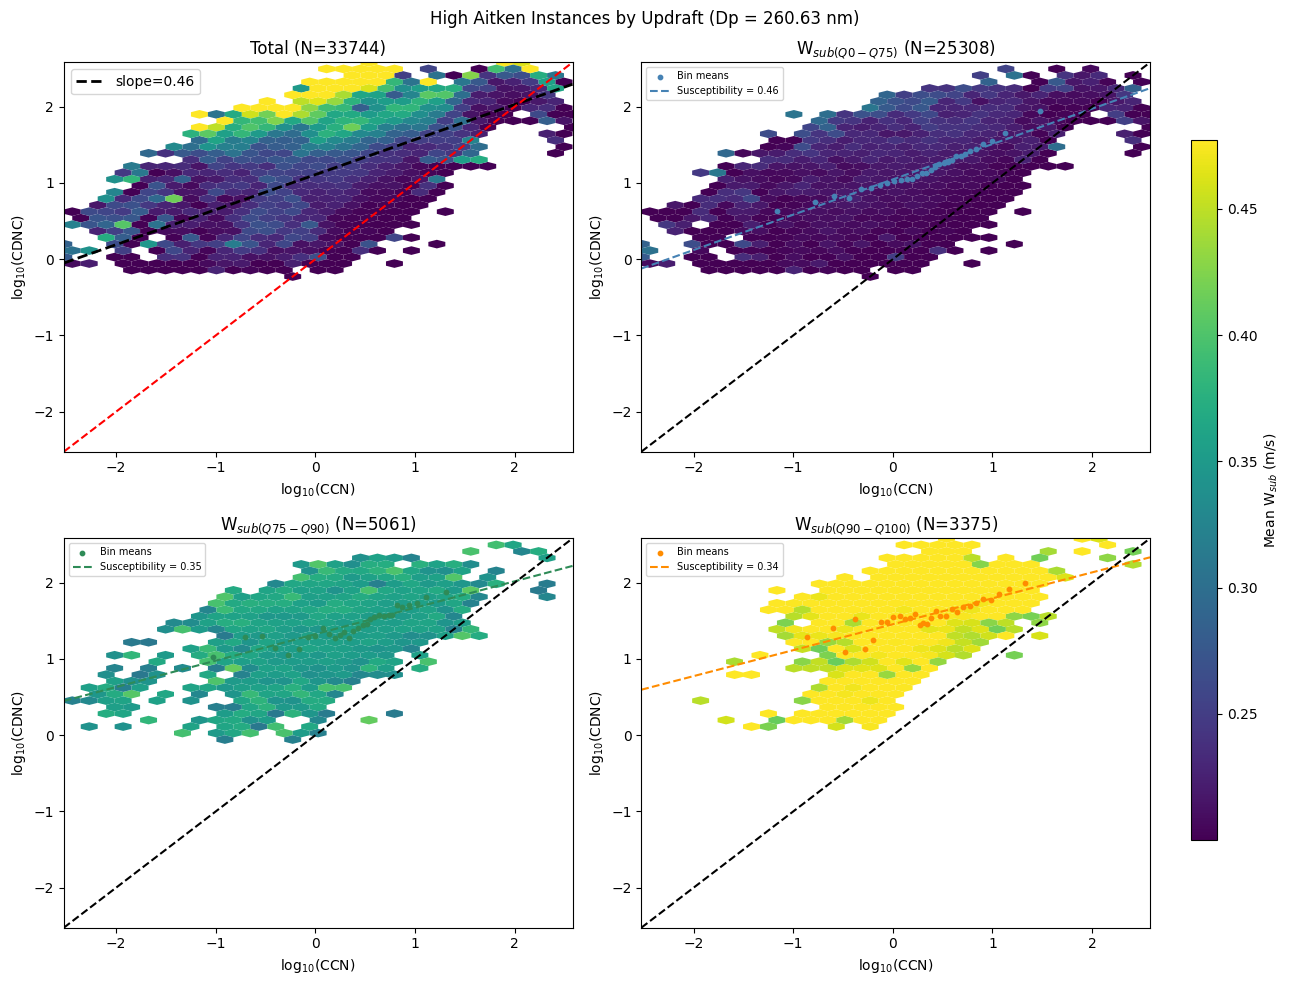

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

r = BigAitReg_ds.slope.sel(updraft_q='Total').argmax().values
wsub = Pairs_ait.Updraft
log_x = np.log10(Pairs_ait['CCN'].isel(radius=r))
log_y = np.log10(Pairs_ait['CDNC'])
xmin = log_x.min().values
xmax = log_x.max().values
ymin = log_y.min().values
ymax = log_y.max().values
Graphmin = np.min([xmin, ymin])
Graphmax = np.max([xmax, ymax])
plotline = np.linspace(Graphmin, Graphmax, 20)


# --- Updraft quantile bands (Q0-Q75 / Q75-Q90 / Q90-Q100) ---
q75, q90, q100 = np.nanquantile(wsub.values, [0.75, 0.90, 1.0])
q0 = np.nanmin(wsub.values)
quartile_bins   = [q0, q75, q90, q100]          # quantile edges from wsub
quartile_labels = ['Q0-Q75', 'Q75-Q90', 'Q90-Q100']
colors = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# --- GLOBAL COLOR SCALE ---
vmin = float(np.nanquantile(wsub, 0.05))
vmax = float(np.nanquantile(wsub, 0.95))

hb_ref = None  # for shared colorbar

# ---------- PANEL 0: TOTAL ----------
ax = axes[0]

valid = np.isfinite(log_x.values) & np.isfinite(log_y.values) & np.isfinite(wsub.values)

lx = log_x.values[valid]
ly = log_y.values[valid]
w  = wsub.values[valid]

n_points = len(lx)

hb = ax.hexbin(
    lx, ly,
    C=w,
    reduce_C_function=np.mean,
    cmap='viridis',
    gridsize=[30, 30],
    vmin=vmin, vmax=vmax,
    mincnt=1,
    edgecolors='none',
    extent=[Graphmin, Graphmax, Graphmin, Graphmax],
)

if hb_ref is None:
    hb_ref = hb

# Total regression
slope = BigAitReg_ds.slope.isel(radius=r).sel(updraft_q='Total').values
intercept = BigAitReg_ds.intercept.isel(radius=r).sel(updraft_q='Total').values

ax.plot(plotline, plotline * slope + intercept,
        color='black', linewidth=2,
        label=f'slope={slope:.2f}', ls='--')

ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
ax.set_title(f'Total (N={n_points})')
ax.legend()


# ---------- QUANTILE BANDS ----------
for i, (lo, hi, label, color) in enumerate(zip(
        quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors)):

    ax = axes[i + 1]

    mask = ((Pairs_ait.Updraft >= lo) & (Pairs_ait.Updraft <= hi)).values

    lx = log_x.values[mask]
    ly = log_y.values[mask]
    w  = wsub.values[mask]

    valid = np.isfinite(lx) & np.isfinite(ly) & np.isfinite(w)
    lx, ly, w = lx[valid], ly[valid], w[valid]

    n_points = len(lx)

    if n_points < 2:
        continue

    # --- HEXBIN ---
    hb = ax.hexbin(
        lx, ly,
        C=w,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=vmin, vmax=vmax,
        mincnt=1,
        edgecolors='none',
        extent=[Graphmin, Graphmax, Graphmin, Graphmax],
    )

    if hb_ref is None:
        hb_ref = hb

    # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
    #     equal datapoint count, take each group's mean ---
    N_BINS = 30
    order = np.argsort(lx)
    lx_groups = np.array_split(lx[order], N_BINS)
    ly_groups = np.array_split(ly[order], N_BINS)

    lx_mean = np.array([np.median(g) for g in lx_groups if g.size > 0])
    ly_mean = np.array([np.median(g) for g in ly_groups if g.size > 0])

    valid_bins = np.isfinite(lx_mean) & np.isfinite(ly_mean)
    lx_mean, ly_mean = lx_mean[valid_bins], ly_mean[valid_bins]

    ax.scatter(lx_mean, ly_mean, color=color, s=10, label='Bin means')


    slope_ds = BigAitReg_ds.slope.isel(radius=r).sel(updraft_q=label).values
    intercept_ds = BigAitReg_ds.intercept.isel(radius=r).sel(updraft_q=label).values

    ax.plot(plotline, plotline * slope_ds + intercept_ds,
            color=color, linestyle='--',
            label=f'Susceptibility = {slope_ds:.2f}')

    ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'k--')

    ax.set_title(f'W$_{{sub ({label})}}$ (N={n_points})')
    ax.legend(fontsize=7)


# ---------- FORMAT ----------
for ax in axes:
    ax.set_xlim([Graphmin, Graphmax])
    ax.set_ylim([Graphmin, Graphmax])
    ax.set_xlabel('log$_{10}$(CCN)')
    ax.set_ylabel('log$_{10}$(CDNC)')


# ---------- OUTSIDE COLORBAR ----------
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(hb_ref, cax=cbar_ax, label='Mean W$_{sub}$ (m/s)')

plt.suptitle(f'High Aitken Instances by Updraft (Dp = {radii[r]*2:.2f} nm)')
plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.show()

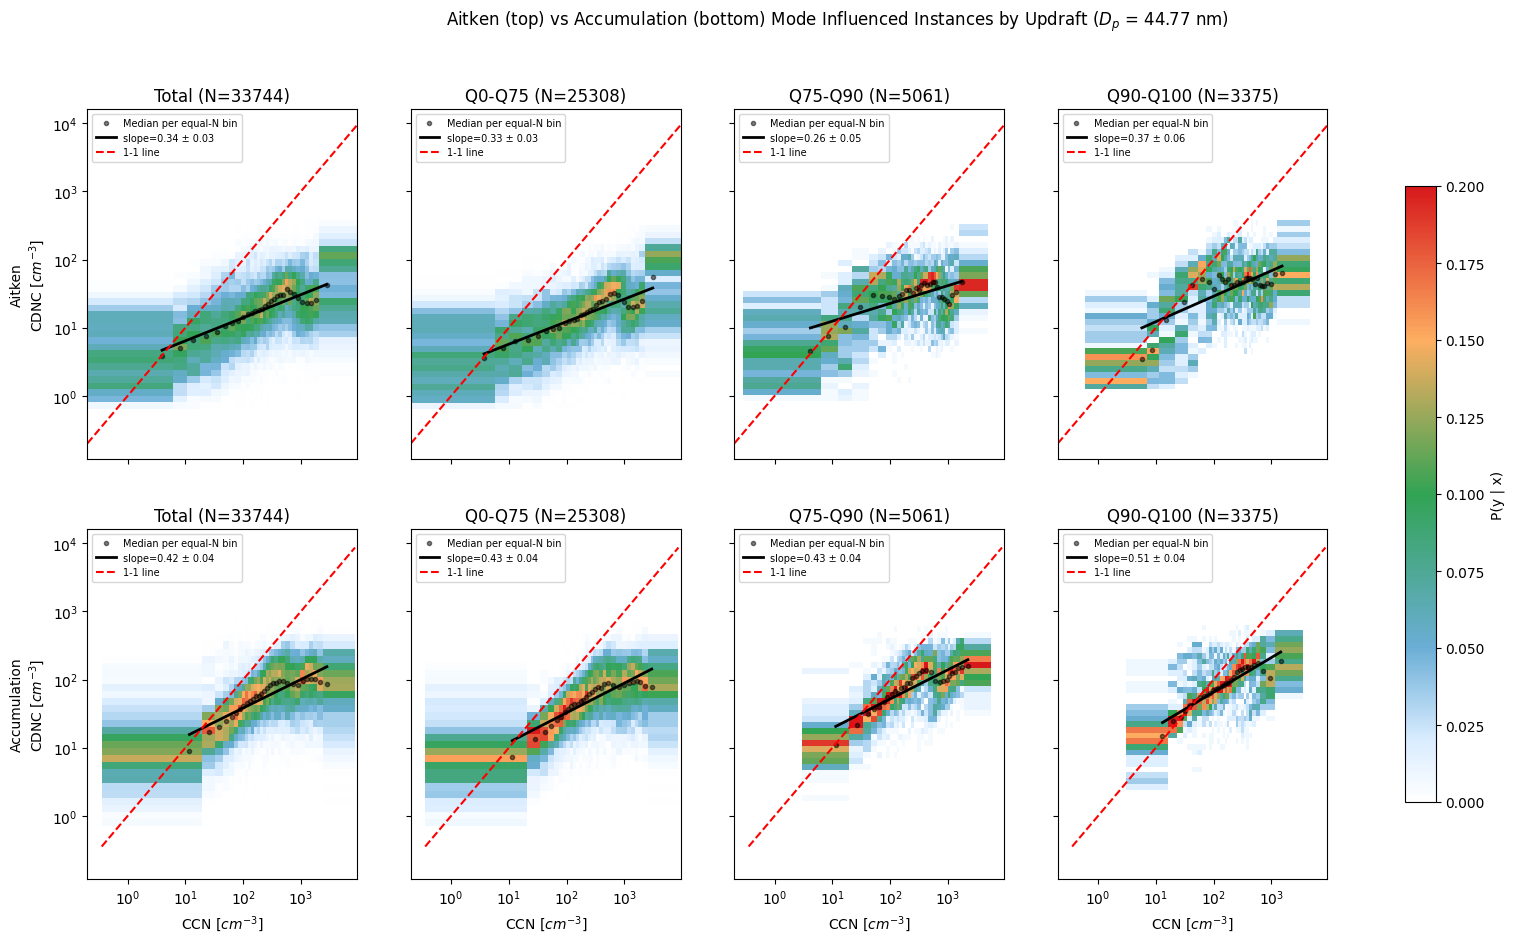

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator

cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)
pow_fmt = FuncFormatter(lambda v, _: rf"$10^{{{int(v)}}}$")

r = 30
n_bins = 30

panels = ['Total', 'Q0-Q75', 'Q75-Q90', 'Q90-Q100']

# one entry per row: (label, Pairs, RegDataset)
rows = [
    ('Aitken',       Pairs_ait, BigAitReg_ds),
    ('Accumulation', Pairs_acc, BigAccReg_ds),
]


def joint_hist(ax, pairs, reg_ds, band_label, wsub, log_x, log_y, g_min, g_max, bands):
    lo, hi = bands[band_label]
    if lo is None:                       # Total: all points
        mask = np.ones_like(wsub, dtype=bool)
    else:
        mask = (wsub >= lo) & (wsub <= hi)

    valid = mask & np.isfinite(log_x) & np.isfinite(log_y)
    lx, ly = log_x[valid], log_y[valid]
    n_points = lx.size
    if n_points < 2:
        ax.set_title(f'{band_label} (N={n_points})')
        return None

    # equal-number x-bins in log space; linear y-bins
    xbins = np.unique(np.quantile(lx, np.linspace(0, 1, n_bins + 1)))
    ybins = np.linspace(ly.min(), ly.max(), 30)
    H, xedges, yedges = np.histogram2d(lx, ly, bins=[xbins, ybins])
    H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))

    pcm = ax.pcolormesh(xedges, yedges, H_norm.T, cmap=cmap,
                        shading="auto", vmin=0, vmax=0.2)

    # equal-count bin medians (sort + array_split)
    order = np.argsort(lx)
    lx_groups = np.array_split(lx[order], n_bins)
    ly_groups = np.array_split(ly[order], n_bins)
    lx_med = np.array([np.median(g) for g in lx_groups if g.size > 0])
    ly_med = np.array([np.median(g) for g in ly_groups if g.size > 0])
    ax.plot(lx_med, ly_med, "k.", alpha=0.5, label="Median per equal-N bin")

    # regression line from the dataset for this band
    slope = float(reg_ds.slope.isel(radius=r).sel(updraft_q=band_label))
    intercept = float(reg_ds.intercept.isel(radius=r).sel(updraft_q=band_label))
    std_err = float(reg_ds.std_err.isel(radius=r).sel(updraft_q=band_label))
    xfit = np.array([lx_med.min(), lx_med.max()])
    ax.plot(xfit, intercept + slope * xfit, "k-", linewidth=2,
            label=f"slope={slope:.2f} ± {1.98*std_err:.2f}")

    ax.plot([g_min, g_max], [g_min, g_max], ls="--", c="red", label="1-1 line")
    ax.set_title(f'{band_label} (N={n_points})')
    ax.legend(fontsize=7, loc='upper left')
    return pcm


fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)

pcm = None
for row_i, (mode_label, pairs, reg_ds) in enumerate(rows):
    wsub  = pairs.Updraft.values
    log_x = np.log10(pairs['CCN'].isel(radius=r)).values
    log_y = np.log10(pairs['CDNC']).values

    finite_all = np.isfinite(log_x) & np.isfinite(log_y)
    g_min = float(min(log_x[finite_all].min(), log_y[finite_all].min()))
    g_max = float(max(log_x[finite_all].max(), log_y[finite_all].max()))

    q75, q90, q100 = np.nanquantile(wsub, [0.75, 0.90, 1.0])
    q0 = np.nanmin(wsub)
    bands = {
        'Total':    (None, None),
        'Q0-Q75':   (q0,   q75),
        'Q75-Q90':  (q75,  q90),
        'Q90-Q100': (q90,  q100),
    }

    for col_i, label in enumerate(panels):
        ax = axes[row_i, col_i]
        result = joint_hist(ax, pairs, reg_ds, label, wsub,
                            log_x, log_y, g_min, g_max, bands)
        if result is not None:
            pcm = result

    # row label on the leftmost panel
    axes[row_i, 0].set_ylabel(f'{mode_label}\nCDNC [$cm^{{-3}}$]')

# shared formatting
for i in range(2):
    for j in range(4):
        ax = axes[i, j]
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_formatter(pow_fmt)
        ax.yaxis.set_major_formatter(pow_fmt)
        if i == 1:                        # bottom row
            ax.set_xlabel("CCN [$cm^{-3}$]")

fig.colorbar(pcm, ax=axes, label="P(y | x)", location='right', shrink=0.8)

plt.suptitle(f'Aitken (top) vs Accumulation (bottom) Mode Influenced Instances '
             f'by Updraft ($D_p$ = {radii[r]*2:.2f} nm)')
plt.show()

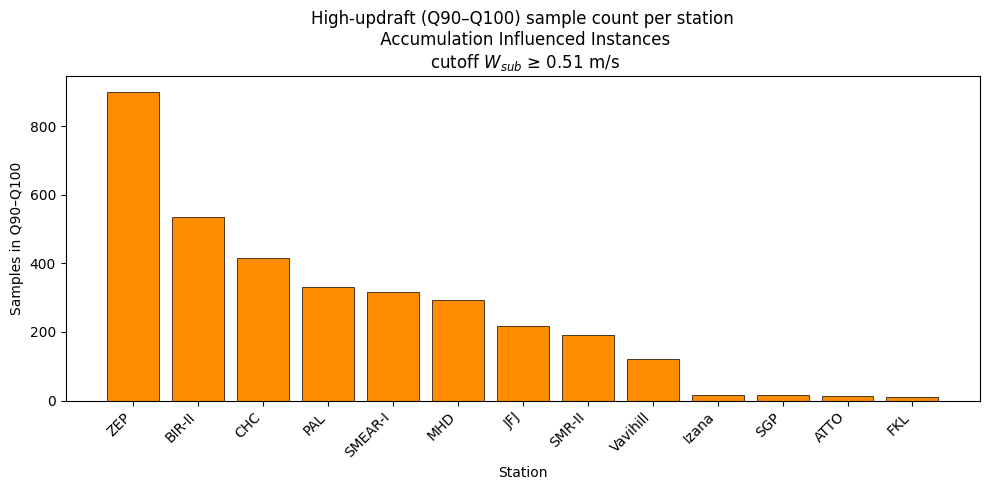

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# global 90th-percentile cutoff over the whole dataset
wsub = np.asarray(Pairs_acc.Updraft)          # realizes the dask array
q90 = np.nanquantile(wsub, 0.90)

stations = np.asarray(Pairs_acc.station)
in_band = np.isfinite(wsub) & (wsub >= q90)

# count Q90–Q100 samples per station
uniq, counts = np.unique(stations[in_band], return_counts=True)
order = np.argsort(counts)[::-1]              # tallest bar first
uniq, counts = uniq[order], counts[order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(uniq, counts, color='darkorange', edgecolor='k', linewidth=0.5)
ax.set_ylabel('Samples in Q90–Q100')
ax.set_xlabel('Station')
ax.set_title(f'High-updraft (Q90–Q100) sample count per station\n Accumulation Influenced Instances\n cutoff $W_{{sub}}$ ≥ {q90:.2f} m/s')
ax.tick_params(axis='x', rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')

plt.tight_layout()
plt.show()

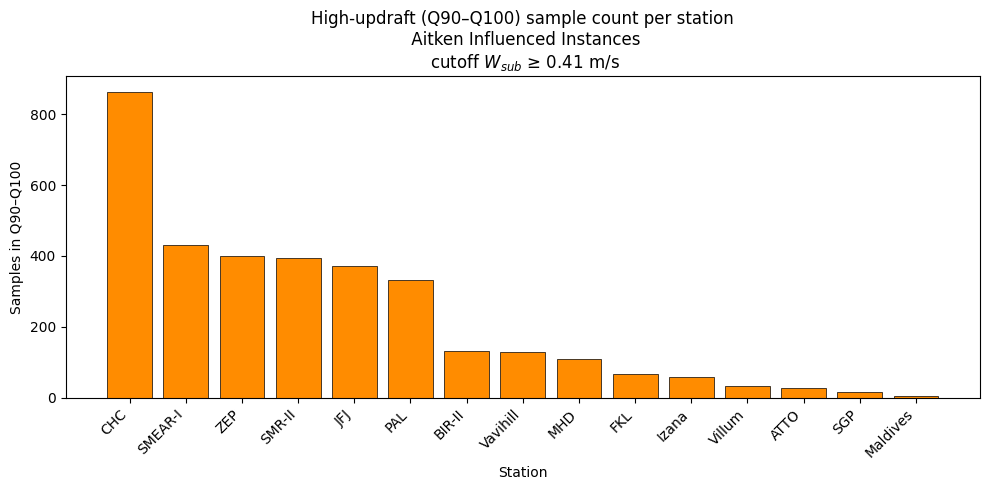

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# global 90th-percentile cutoff over the whole dataset
wsub = np.asarray(Pairs_ait.Updraft)          # realizes the dask array
q90 = np.nanquantile(wsub, 0.90)

stations = np.asarray(Pairs_ait.station)
in_band = np.isfinite(wsub) & (wsub >= q90)

# count Q90–Q100 samples per station
uniq, counts = np.unique(stations[in_band], return_counts=True)
order = np.argsort(counts)[::-1]              # tallest bar first
uniq, counts = uniq[order], counts[order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(uniq, counts, color='darkorange', edgecolor='k', linewidth=0.5)
ax.set_ylabel('Samples in Q90–Q100')
ax.set_xlabel('Station')
ax.set_title(f'High-updraft (Q90–Q100) sample count per station\n Aitken Influenced Instances\n cutoff $W_{{sub}}$ ≥ {q90:.2f} m/s')
ax.tick_params(axis='x', rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2027234/3401028047.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


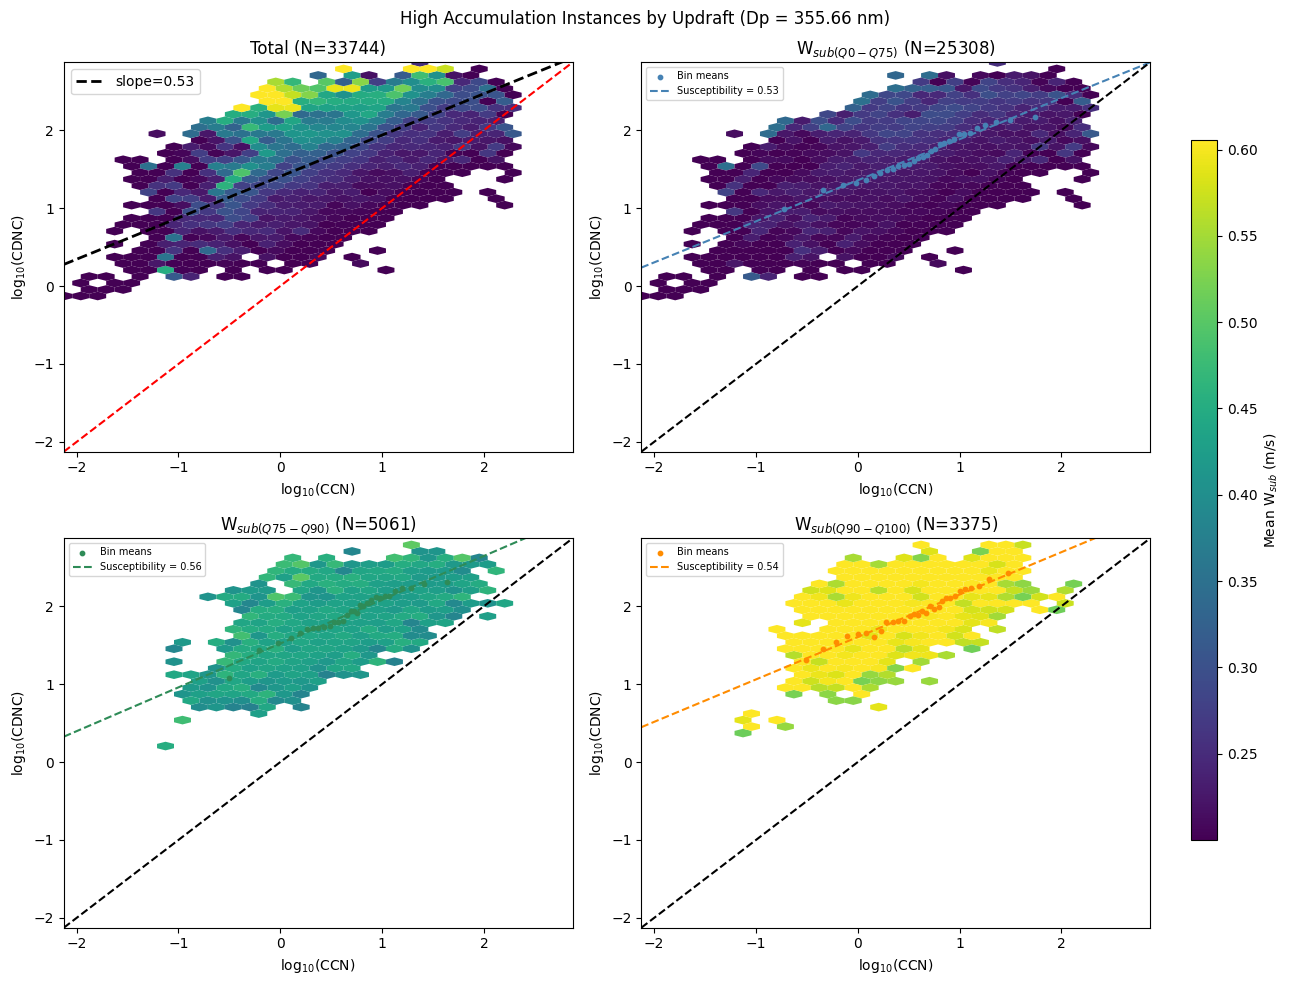

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

r = BigAccReg_ds.slope.sel(updraft_q='Total').argmax().values
wsub = Pairs_acc.Updraft
log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
log_y = np.log10(Pairs_acc['CDNC'])
xmin = log_x.min().values
xmax = log_x.max().values
ymin = log_y.min().values
ymax = log_y.max().values
Graphmin = np.min([xmin, ymin])
Graphmax = np.max([xmax, ymax])
plotline = np.linspace(Graphmin, Graphmax, 20)


# --- Updraft quantile bands (Q0-Q75 / Q75-Q90 / Q90-Q100) ---
q75, q90, q100 = np.nanquantile(wsub.values, [0.75, 0.90, 1.0])
q0 = np.nanmin(wsub.values)
quartile_bins   = [q0, q75, q90, q100]          # quantile edges from wsub
quartile_labels = ['Q0-Q75', 'Q75-Q90', 'Q90-Q100']
colors = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# --- GLOBAL COLOR SCALE ---
vmin = float(np.nanquantile(wsub, 0.05))
vmax = float(np.nanquantile(wsub, 0.95))

hb_ref = None  # for shared colorbar

# ---------- PANEL 0: TOTAL ----------
ax = axes[0]

valid = np.isfinite(log_x.values) & np.isfinite(log_y.values) & np.isfinite(wsub.values)

lx = log_x.values[valid]
ly = log_y.values[valid]
w  = wsub.values[valid]

n_points = len(lx)

hb = ax.hexbin(
    lx, ly,
    C=w,
    reduce_C_function=np.mean,
    cmap='viridis',
    gridsize=[30, 30],
    vmin=vmin, vmax=vmax,
    mincnt=1,
    edgecolors='none',
    extent=[Graphmin, Graphmax, Graphmin, Graphmax],
)

if hb_ref is None:
    hb_ref = hb

# Total regression
slope = BigAccReg_ds.slope.isel(radius=r).sel(updraft_q='Total').values
intercept = BigAccReg_ds.intercept.isel(radius=r).sel(updraft_q='Total').values

ax.plot(plotline, plotline * slope + intercept,
        color='black', linewidth=2,
        label=f'slope={slope:.2f}', ls='--')

ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
ax.set_title(f'Total (N={n_points})')
ax.legend()


# ---------- QUANTILE BANDS ----------
for i, (lo, hi, label, color) in enumerate(zip(
        quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors)):

    ax = axes[i + 1]

    mask = ((Pairs_acc.Updraft >= lo) & (Pairs_acc.Updraft <= hi)).values

    lx = log_x.values[mask]
    ly = log_y.values[mask]
    w  = wsub.values[mask]

    valid = np.isfinite(lx) & np.isfinite(ly) & np.isfinite(w)
    lx, ly, w = lx[valid], ly[valid], w[valid]

    n_points = len(lx)

    if n_points < 2:
        continue

    # --- HEXBIN ---
    hb = ax.hexbin(
        lx, ly,
        C=w,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=vmin, vmax=vmax,
        mincnt=1,
        edgecolors='none',
        extent=[Graphmin, Graphmax, Graphmin, Graphmax],
    )

    if hb_ref is None:
        hb_ref = hb

    # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
    #     equal datapoint count, take each group's mean ---
    N_BINS = 30
    order = np.argsort(lx)
    lx_groups = np.array_split(lx[order], N_BINS)
    ly_groups = np.array_split(ly[order], N_BINS)

    lx_mean = np.array([np.median(g) for g in lx_groups if g.size > 0])
    ly_mean = np.array([np.median(g) for g in ly_groups if g.size > 0])

    valid_bins = np.isfinite(lx_mean) & np.isfinite(ly_mean)
    lx_mean, ly_mean = lx_mean[valid_bins], ly_mean[valid_bins]

    ax.scatter(lx_mean, ly_mean, color=color, s=10, label='Bin means')


    slope_ds = BigAccReg_ds.slope.isel(radius=r).sel(updraft_q=label).values
    intercept_ds = BigAccReg_ds.intercept.isel(radius=r).sel(updraft_q=label).values

    ax.plot(plotline, plotline * slope_ds + intercept_ds,
            color=color, linestyle='--',
            label=f'Susceptibility = {slope_ds:.2f}')

    ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'k--')

    ax.set_title(f'W$_{{sub ({label})}}$ (N={n_points})')
    ax.legend(fontsize=7)


# ---------- FORMAT ----------
for ax in axes:
    ax.set_xlim([Graphmin, Graphmax])
    ax.set_ylim([Graphmin, Graphmax])
    ax.set_xlabel('log$_{10}$(CCN)')
    ax.set_ylabel('log$_{10}$(CDNC)')


# ---------- OUTSIDE COLORBAR ----------
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(hb_ref, cax=cbar_ax, label='Mean W$_{sub}$ (m/s)')

plt.suptitle(f'High Accumulation Instances by Updraft (Dp = {radii[r]*2:.2f} nm)')
plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.show()

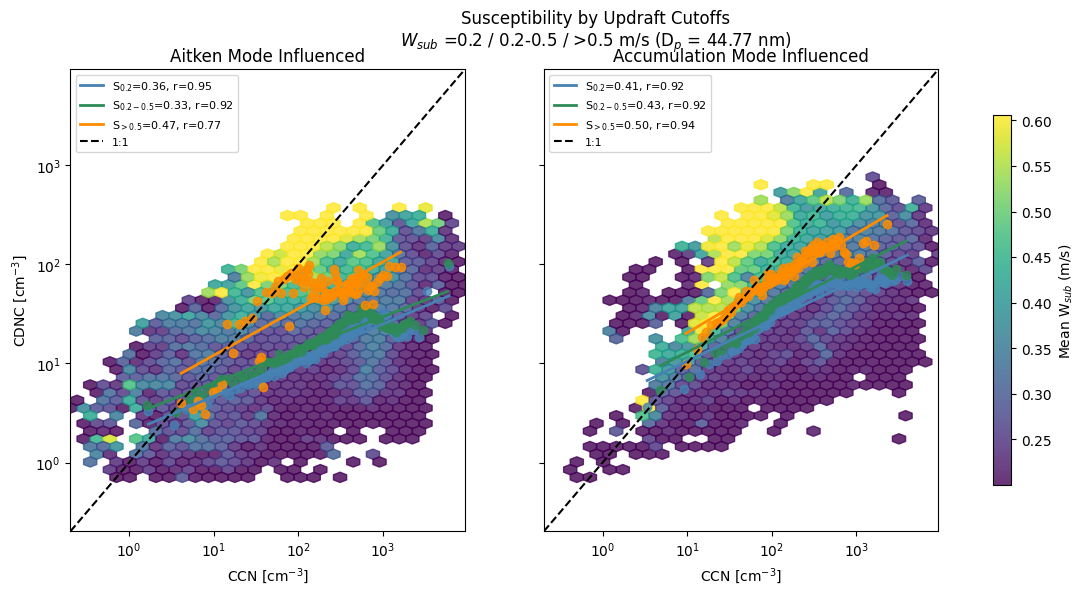

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

pow_fmt = FuncFormatter(lambda v, _: rf"$10^{{{int(v)}}}$")

r = 30
n_bins = 100

# one entry per panel: (title_mode, Pairs)
panels = [
    ('Aitken Mode Influenced',       Pairs_ait),
    ('Accumulation Mode Influenced', Pairs_acc),
]

# --- Fixed physical updraft bins (match the module's bin scheme) ---
quartile_bins   = [0.0, 0.2, 0.5, np.inf]   # edges for <=0.2 / 0.2-0.5 / >0.5
quartile_labels = ['0.2', '0.2-0.5', '>0.5']
colors = ['steelblue', 'seagreen', 'darkorange']

# --- global axis range across BOTH modes so panels share one scale ---
Graphmin, Graphmax = np.inf, -np.inf
for _, pairs in panels:
    lx = np.log10(pairs['CCN'].isel(radius=r)).values
    ly = np.log10(pairs['CDNC']).values
    finite = np.isfinite(lx) & np.isfinite(ly)
    Graphmin = min(Graphmin, lx[finite].min(), ly[finite].min())
    Graphmax = max(Graphmax, lx[finite].max(), ly[finite].max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

hb = None
for ax, (mode_label, pairs) in zip(axes, panels):
    wsub = pairs.Updraft
    log_x = np.log10(pairs['CCN'].isel(radius=r))
    log_y = np.log10(pairs['CDNC'])

    # Hexbin background
    hb = ax.hexbin(
        log_x, log_y,
        C=wsub,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=float(np.quantile(wsub, 0.05)),
        vmax=float(np.quantile(wsub, 0.95)),
        mincnt=1,
        extent=[Graphmin, Graphmax, Graphmin, Graphmax],
        alpha=0.8,
    )

    # --- Per-quartile regression ---
    for lo, hi, label, color in zip(
            quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors):

        lx = log_x.where((pairs.Updraft >= lo) & (pairs.Updraft <= hi)).values
        ly = log_y.where((pairs.Updraft >= lo) & (pairs.Updraft <= hi)).values

        valid = np.isfinite(lx) & np.isfinite(ly)
        lx, ly = lx[valid], ly[valid]
        if len(lx) < 2:
            continue

        # Equal-count bins: sort by x, split into n_bins groups, median per bin
        order = np.argsort(lx)
        lx_groups = np.array_split(lx[order], n_bins)
        ly_groups = np.array_split(ly[order], n_bins)
        lx_med = np.array([np.median(g) for g in lx_groups if g.size > 0])
        ly_med = np.array([np.median(g) for g in ly_groups if g.size > 0])

        if len(lx_med) < 2:
            continue

        slope, intercept, r_value, p_value, std_err = stats.linregress(lx_med, ly_med)
        ax.scatter(lx_med, ly_med, color=color, alpha=0.8)
        xfit = np.array([lx_med.min(), lx_med.max()])
        ax.plot(xfit, xfit * slope + intercept,
                color=color, linewidth=2,
                label=f'S$_{{{label}}}$={slope:.2f}, r={r_value:.2f}')

    # 1:1 reference
    ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'k--', label='1:1')

    ax.set_xlim([Graphmin, Graphmax])
    ax.set_ylim([Graphmin, Graphmax])

    # power-of-ten tick labels instead of raw log10 values
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(pow_fmt)
    ax.yaxis.set_major_formatter(pow_fmt)

    ax.set_xlabel('CCN [cm$^{-3}$]')
    ax.set_title(mode_label)
    ax.legend(fontsize=8)

axes[0].set_ylabel('CDNC [cm$^{-3}$]')

fig.colorbar(hb, ax=axes, label='Mean W$_{sub}$ (m/s)', shrink=0.8)
fig.suptitle(f'Susceptibility by Updraft Cutoffs\n'
             f'$W_{{sub}}$ =0.2 / 0.2-0.5 / >0.5 m/s (D$_p$ = {radii[r]*2:.2f} nm)')
plt.show()

Updraft CDFs — note the 0.2 m/s floor from `WSUB = max(sqrt(WP2_CLUBB), 0.2)`.

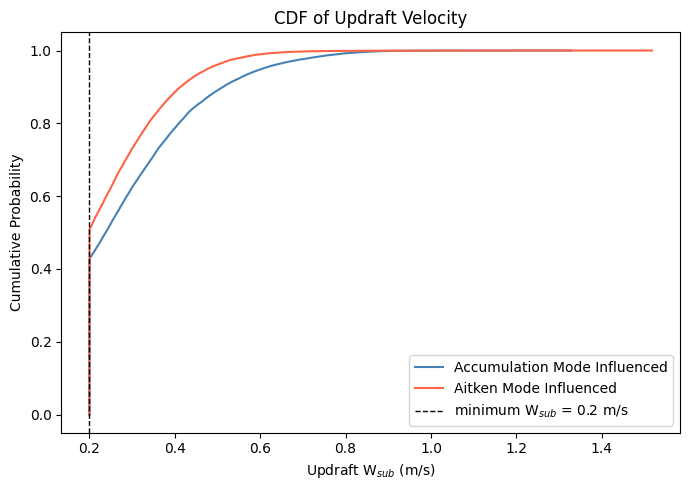

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))

for data, label, color in [
    (Pairs_acc.Updraft.values, 'Accumulation Mode Influenced', 'steelblue'),
    (Pairs_ait.Updraft.values, 'Aitken Mode Influenced', 'tomato'),
]:
    vals = data[np.isfinite(data)]
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
    ax.plot(vals_sorted, cdf, label=label, color=color)

ax.axvline(0.2, color='k', linestyle='--', linewidth=1, label='minimum W$_{sub}$ = 0.2 m/s')
ax.set_xlabel('Updraft W$_{sub}$ (m/s)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of Updraft Velocity')
ax.legend()
plt.tight_layout()
plt.show()

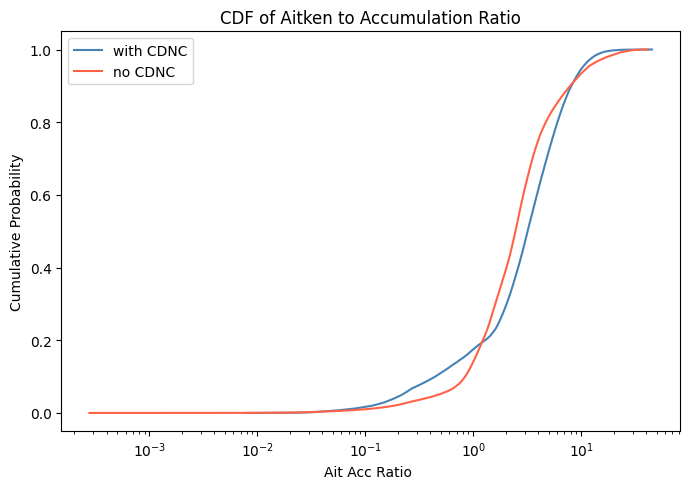

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))

for data, label, color in [
    (AitAccRatio.values, 'with CDNC', 'steelblue'),
    (AitAccRatio2.values, 'no CDNC', 'tomato'),
]:
    vals = data[np.isfinite(data)]
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
    ax.plot(vals_sorted, cdf, label=label, color=color)
ax.set_xscale('log')
ax.set_xlabel('Ait Acc Ratio ')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of Aitken to Accumulation Ratio')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Mode occurrence by pressure level

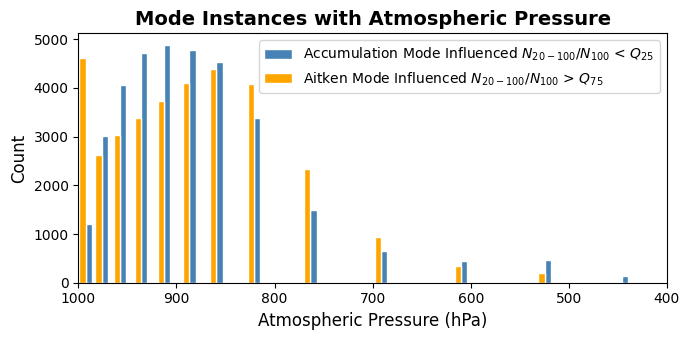

In [40]:


# Count occurrences


# Align both series to the same index
acc_count = acc_count.reindex(all_levels, fill_value=0)
ait_count = ait_count.reindex(all_levels, fill_value=0)

# Width based on minimum spacing between pressure levels
min_spacing = np.diff(np.sort(all_levels)).min()
width = min_spacing * 0.4

fig, ax = plt.subplots(figsize=(7, 3.5))
bars1 = ax.bar(all_levels - width/2, acc_count.values, width=width,
               color='steelblue', edgecolor='white', label='Accumulation Mode Influenced $N_{20-100}/N_{100}$ < $Q_{25}$')
bars2 = ax.bar(all_levels + width/2, ait_count.values, width=width,
               color='orange', edgecolor='white', label='Aitken Mode Influenced $N_{20-100}/N_{100}$ > $Q_{75}$')
ax.set_xlim([1000,400])
ax.set_xlabel('Atmospheric Pressure (hPa)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Mode Instances with Atmospheric Pressure', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Per-level susceptibility curves

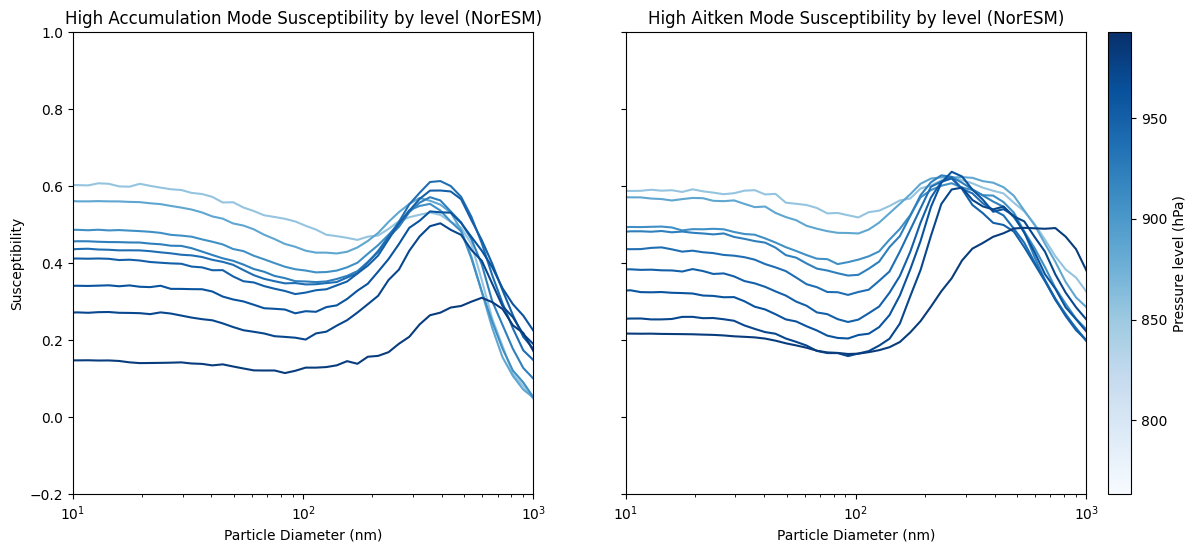

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# --- Per-level sample counts; keep only levels with > 1000 points ---
acc_count = pd.Series(Pairs_acc.lev.values).value_counts()
ait_count = pd.Series(Pairs_ait.lev.values).value_counts()

acc_levels = [l for l in BigAccReg_lev_ds.lev.values if acc_count.get(l, 0) > 1000]
ait_levels = [l for l in BigAitReg_lev_ds.lev.values if ait_count.get(l, 0) > 1000]

# --- Shared color scale across BOTH panels (map pressure level -> color) ---
all_levels = np.array(acc_levels + ait_levels, dtype=float)
norm = Normalize(vmin=all_levels.min(), vmax=all_levels.max())
cmap = cm.Blues

def level_color(lev_val):
    # rescale into 0.4-0.95 so no near-white lines, but keep a shared mapping
    return cmap(0.4 + 0.55 * norm(lev_val))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

panels = [
    (axes[0], BigAccReg_lev_ds, acc_levels, 'High Accumulation Mode Susceptibility by level (NorESM)'),
    (axes[1], BigAitReg_lev_ds, ait_levels, 'High Aitken Mode Susceptibility by level (NorESM)'),
]

for ax, ds, levels, title in panels:
    for lev_val in levels:
        ax.plot(
            ds.radius * 2,
            ds.slope.sel(lev=lev_val),
            color=level_color(lev_val),
            label=f'{lev_val:.2f} hPa',
        )
    ax.set_xscale('log')
    ax.set_xlabel('Particle Diameter (nm)')
    ax.set_title(title)
    ax.set_xlim([10, 1000])
    ax.set_ylim([-0.2, 1])

axes[0].set_ylabel('Susceptibility')

# --- Single shared colorbar (continuous pressure scale) ---
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.02)
cbar.set_label('Pressure level (hPa)')

plt.show()